# 1.0 - Exploratory data analysis

First look at the E-Commerce churn dataset before any modelling. The findings here drove three decisions in the pipeline: category spellings are merged in `make_dataset`, missing values are median-imputed in `build_features`, and the metrics are rank-based because the classes are imbalanced.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from churn import config
from churn.data.make_dataset import clean, load_raw

raw = load_raw()
raw.shape

(5630, 20)

## Target balance

About one customer in six churns, so accuracy is a misleading metric: predicting 'no churn' for everyone is already ~83% accurate.

In [2]:
raw[config.TARGET].value_counts(normalize=True).rename('share').to_frame()

,share
Churn,
0,0.831616
1,0.168384


## Missing values

Seven numeric columns have 4-6% missing values. None is missing often enough to drop; the pipeline imputes the median.

In [3]:
missing = raw.isna().mean().mul(100).round(2)
missing[missing > 0].sort_values(ascending=False).rename('% missing').to_frame()

,% missing
DaySinceLastOrder,5.45
OrderAmountHikeFromlastYear,4.71
Tenure,4.69
OrderCount,4.58
CouponUsed,4.55
HourSpendOnApp,4.53
WarehouseToHome,4.46


## Inconsistent categories

The same value is spelled several ways - `Phone` / `Mobile Phone`, `CC` / `Credit Card`, `COD` / `Cash on Delivery`, `Mobile` / `Mobile Phone`. Left alone, one-hot encoding would split each into separate columns.

In [4]:
for col in config.CATEGORICAL_FEATURES:
    print(col, sorted(raw[col].dropna().unique()))

PreferredLoginDevice ['Computer', 'Mobile Phone', 'Phone']
PreferredPaymentMode ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
Gender ['Female', 'Male']
PreferedOrderCat ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']
MaritalStatus ['Divorced', 'Married', 'Single']


In [5]:
df = clean(raw)
for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(col, sorted(df[col].dropna().unique()))

PreferredLoginDevice ['Computer', 'Phone']
PreferredPaymentMode ['Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
PreferedOrderCat ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Others']


## Churn rate by segment

Complaints, short tenure and single customers stand out. These are the kinds of drivers the part 1 framing expected to surface as reason codes.

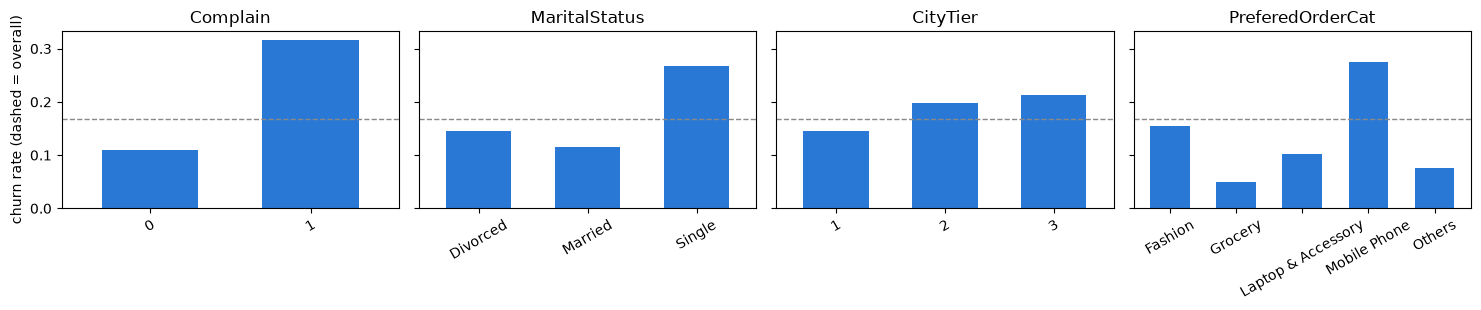

In [6]:
rates = {
    'Complain': df.groupby('Complain')[config.TARGET].mean(),
    'MaritalStatus': df.groupby('MaritalStatus')[config.TARGET].mean(),
    'CityTier': df.groupby('CityTier')[config.TARGET].mean(),
    'PreferedOrderCat': df.groupby('PreferedOrderCat')[config.TARGET].mean(),
}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, (name, series) in zip(axes, rates.items()):
    series.plot.bar(ax=ax, color='#2a78d6', width=0.6)
    ax.axhline(df[config.TARGET].mean(), color='#8a8985', linestyle='--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('churn rate (dashed = overall)')
fig.tight_layout()

## Tenure

Churn is concentrated in the first months: most churners have a tenure of 0-1.

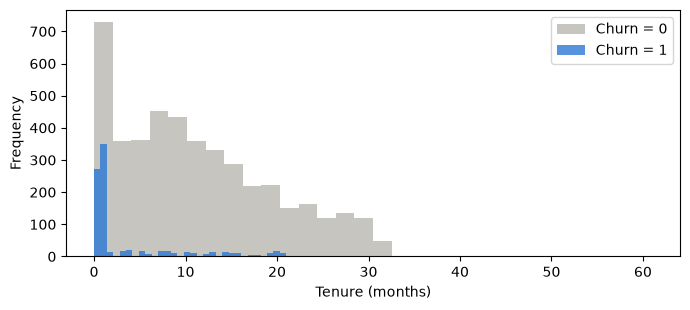

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for label, colour in [(0, '#b9b7b0'), (1, '#2a78d6')]:
    df.loc[df[config.TARGET] == label, 'Tenure'].plot.hist(ax=ax, bins=30, alpha=0.8, color=colour,
                                                            label=f'Churn = {label}')
ax.set_xlabel('Tenure (months)')
ax.legend()
fig.tight_layout()

In [8]:
df.groupby(config.TARGET)[['Tenure', 'DaySinceLastOrder', 'CashbackAmount', 'SatisfactionScore']].median()

,Tenure,DaySinceLastOrder,CashbackAmount,SatisfactionScore
Churn,,,,
0,10.0,4.0,166.115,3.0
1,1.0,2.0,149.660,3.0


## Correlation with the target

Linear correlation only - the tree models capture interactions this table cannot show.

In [9]:
df[config.NUMERIC_FEATURES + [config.TARGET]].corr()[config.TARGET].drop(config.TARGET)\
  .sort_values(key=abs, ascending=False).round(3).to_frame()

,Churn
Tenure,-0.349
Complain,0.250
DaySinceLastOrder,-0.161
CashbackAmount,-0.154
NumberOfDeviceRegistered,0.108
SatisfactionScore,0.105
CityTier,0.085
WarehouseToHome,0.077
NumberOfAddress,0.044
OrderCount,-0.029


## Takeaways for the pipeline

1. **Imbalance (17%)** - use PR-AUC and lift, stratify the split, weight the classes.
2. **Missing values** - median imputation inside the pipeline, so training and serving treat them identically.
3. **Duplicate spellings** - merged in `make_dataset.harmonise_categories`.
4. **Tenure and complaints** dominate - ratios such as orders per month of tenure are added in `build_features`.
5. **Static snapshot** - no time axis, so the out-of-time validation from part 1 cannot be reproduced; results will be optimistic.